### **Cell 1: Imports and Setup**

This cell imports necessary libraries such as `numpy` for numerical operations, `pandas` for data manipulation, and `matplotlib.pyplot` for plotting. It also sets up a plotting style and a random seed for reproducibility.

In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from math import sqrt

plt.style.use("seaborn-v0_8-whitegrid")
np.set_printoptions(precision=3, suppress=True)
# generator is the class and default_rng is the constructor of the class -
# rng here is the object that is ready to produce high quality random numbers based on PCG64 alogorithm(permuted Congruential generator)

RANDOM_SEED = 42
rng = np.random.default_rng(RANDOM_SEED)
print (rng)

Generator(PCG64)


### **Cell 2: Synthetic Data Generation**

This cell generates synthetic data for 'experience_years' and 'salary'. It creates an array of experience years, adds random noise to simulate real-world variability, and then calculates a corresponding salary. Finally, it creates a pandas DataFrame from this data and displays the first few rows.

In [29]:
n = 45
experience = np.linspace(0.5, 10, n)
noise = rng.normal(loc=0, scale=6500, size=n)
salary = 30000 + 8000 * experience + noise

df = pd.DataFrame({
    "experience_years": experience,
    "salary": salary
})
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45 entries, 0 to 44
Data columns (total 2 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   experience_years  45 non-null     float64
 1   salary            45 non-null     float64
dtypes: float64(2)
memory usage: 852.0 bytes


,experience_years,salary
0,0.500000,27398.735972
1,0.715909,37765.112736
2,0.931818,42902.368146
3,1.147727,52160.568978
4,1.363636,59849.196938


### **Cell 3: Data Visualization - Scatter Plot**

This cell visualizes the generated data using a scatter plot. It shows the relationship between 'experience_years' and 'salary', providing an initial understanding of the data distribution.

fig: The Figure object, which is the top-level container for all plot elements. Think of it as the canvas on which you're drawing.
ax: The Axes object (or an array of Axes objects if you create multiple subplots). This is the actual plotting area where the data is drawn. Most plotting functions you'll use (like scatter, plot, set_title) are methods of this Axes object.

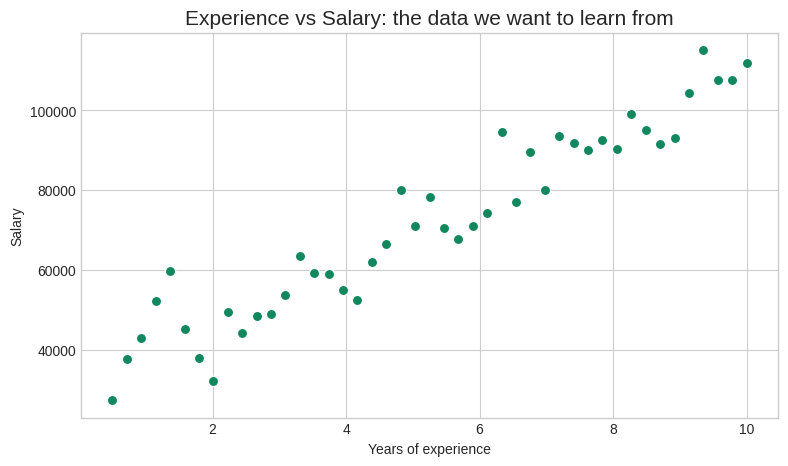

In [34]:
fig, ax = plt.subplots(figsize=(9, 5)) #figsize=(9, 5): This is a parameter passed to plt.subplots() that sets the size of the figure.
#It takes a tuple (width, height) in inches. In this case, the figure will be 9 inches wide and 5 inches tall.
ax.scatter(df["experience_years"], df["salary"], s=55, color="#11875d", edgecolor="white") # 55 - size id the each point
ax.set_title("Experience vs Salary: the data we want to learn from", fontsize=15)
ax.set_xlabel("Years of experience")
ax.set_ylabel("Salary")
plt.show()

### **Cell 4: Helper Functions for Regression Line and Residuals**

This cell defines two helper functions: `predict_line` to calculate predicted salaries based on a given slope and intercept, and `plot_line_with_residuals` to visualize a regression line along with its residuals (the vertical distances between actual and predicted points). It then demonstrates the `plot_line_with_residuals` function with example values.

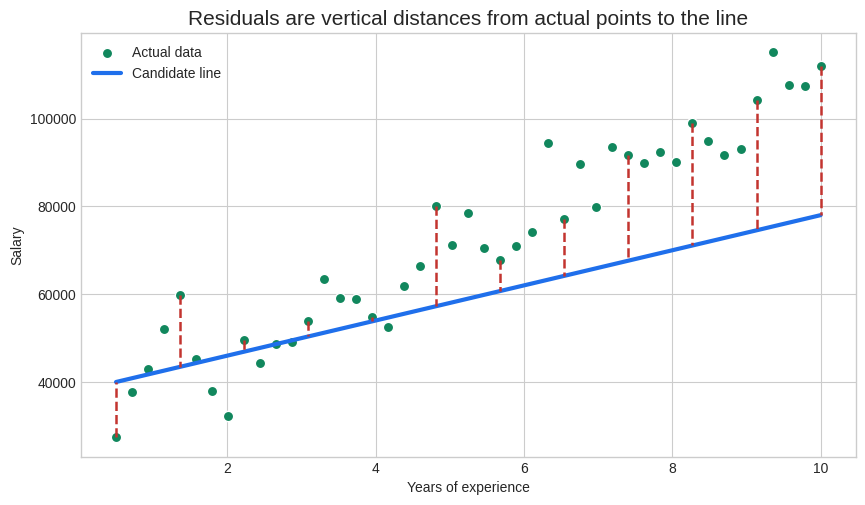

In [36]:
def plot_line_with_residuals(slope, intercept, title):
    x = df["experience_years"].to_numpy()
    y = df["salary"].to_numpy()
    y_pred = predict_line(x, slope, intercept)

    fig, ax = plt.subplots(figsize=(10, 5.5))
    ax.scatter(x, y, s=55, color="#11875d", edgecolor="white", label="Actual data")
    ax.plot(x, y_pred, color="#1f6feb", linewidth=3, label="Candidate line")

    # Draw residuals for a subset so the chart stays readable.
    subset = np.arange(0, len(x), 4)
    for i in subset:
        ax.plot([x[i], x[i]], [y[i], y_pred[i]], color="#c3342f", linestyle="--", linewidth=1.8)

    ax.set_title(title, fontsize=15)
    ax.set_xlabel("Years of experience")
    ax.set_ylabel("Salary")
    ax.legend()
    plt.show()

def predict_line(x, slope, intercept):
    return slope * x + intercept

plot_line_with_residuals(
    slope=4000,
    intercept=38000,
    title="Residuals are vertical distances from actual points to the line"
)


### **Cell 5: Regression Metrics Function**

This cell defines a function `regression_metrics` that calculates common regression evaluation metrics such as Residual Sum of Squares (RSS), Mean Squared Error (MSE), Root Mean Squared Error (RMSE), and Mean Absolute Error (MAE). These metrics are used to quantify the performance of a regression model.

### **Understanding Regression Metrics in Relation to Residuals**

The plot above (from Cell 4) visualizes **residuals**, which are the vertical distances between the actual data points and the regression line. These residuals are crucial for understanding how well a model fits the data. The regression metrics defined in Cell 5 quantify these residuals:

*   **Residual Sum of Squares (RSS):** This is the sum of the squares of the residuals. It directly measures the total squared error of the model. A smaller RSS indicates a better fit.

*   **Mean Squared Error (MSE):** This is the average of the squares of the residuals. It provides a single value representing the average magnitude of the squared errors. Like RSS, smaller MSE means a better fit.*** Squaring the errors penalizes larger errors more heavily.***

*   **Root Mean Squared Error (RMSE):** This is the square root of the MSE. RMSE is often preferred over MSE because it has the same units as the dependent variable (salary in this case), making it easier to interpret. It represents the standard deviation of the residuals.

*   **Mean Absolute Error (MAE):** This is the average of the absolute values of the residuals. MAE is also in the same units as the dependent variable, but unlike RMSE, it treats all errors equally, regardless of their magnitude. It's less sensitive to outliers than MSE or RMSE.

In [39]:
def regression_metrics(y_true, y_pred):
    n = len(y_true)
    errors = y_true - y_pred
    rss = ((errors) ** 2).sum()
    mse = np.mean(errors ** 2)
    rmse = np.sqrt(mse)
    mae = np.mean(np.abs(errors))

    return {
        "rss": rss,
        "mse": mse,
        "rmse": rmse,
        "mae": mae
    }

### **Cell 6: Comparing Candidate Regression Models**

This cell defines several candidate linear regression models with different slopes and intercepts. It then iterates through these models, uses the `predict_line` and `regression_metrics` functions to evaluate each model, and stores the results in a DataFrame, which is then displayed. This helps in comparing the performance of different model parameters.

In [35]:
x = df["experience_years"].to_numpy()
y = df["salary"].to_numpy()

candidate_models = [
    {"name": "Line A: too flat", "slope": 4000, "intercept": 48000},
    {"name": "Line B: better", "slope": 8224.170483411222, "intercept": 29184},
    {"name": "Line C: too steep", "slope": 11500, "intercept": 15000},
]

rows = []
for model in candidate_models:
    y_pred = predict_line(x, model["slope"], model["intercept"])
    metrics = regression_metrics(y, y_pred)
    rows.append({
        "model": model["name"],
        "slope": model["slope"],
        "intercept": model["intercept"],
        "MAE": metrics["mae"],
        "RMSE": metrics["rmse"],
        "MSE": metrics["mse"],
        "RSS": metrics["rss"]
    })

metrics_df = pd.DataFrame(rows)
metrics_df

,model,slope,intercept,MAE,RMSE,MSE,RSS
0,Line A: too flat,4000.000000,48000,10942.907644,13318.187553,1.773741e+08,7.981835e+09
1,Line B: better,8224.170483,29184,4193.068754,5077.194453,2.577790e+07,1.160006e+09
2,Line C: too steep,11500.000000,15000,9218.191865,10919.528946,1.192361e+08,5.365625e+09


### **Cell 7: Visualizing Candidate Regression Models**

This cell creates a series of scatter plots, each displaying one of the candidate regression lines along with the actual data. The title of each subplot includes the RMSE for that model, visually demonstrating how different lines fit the data and their corresponding error values.

) missing from font(s) Liberation Sans.
  plt.tight_layout()
) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


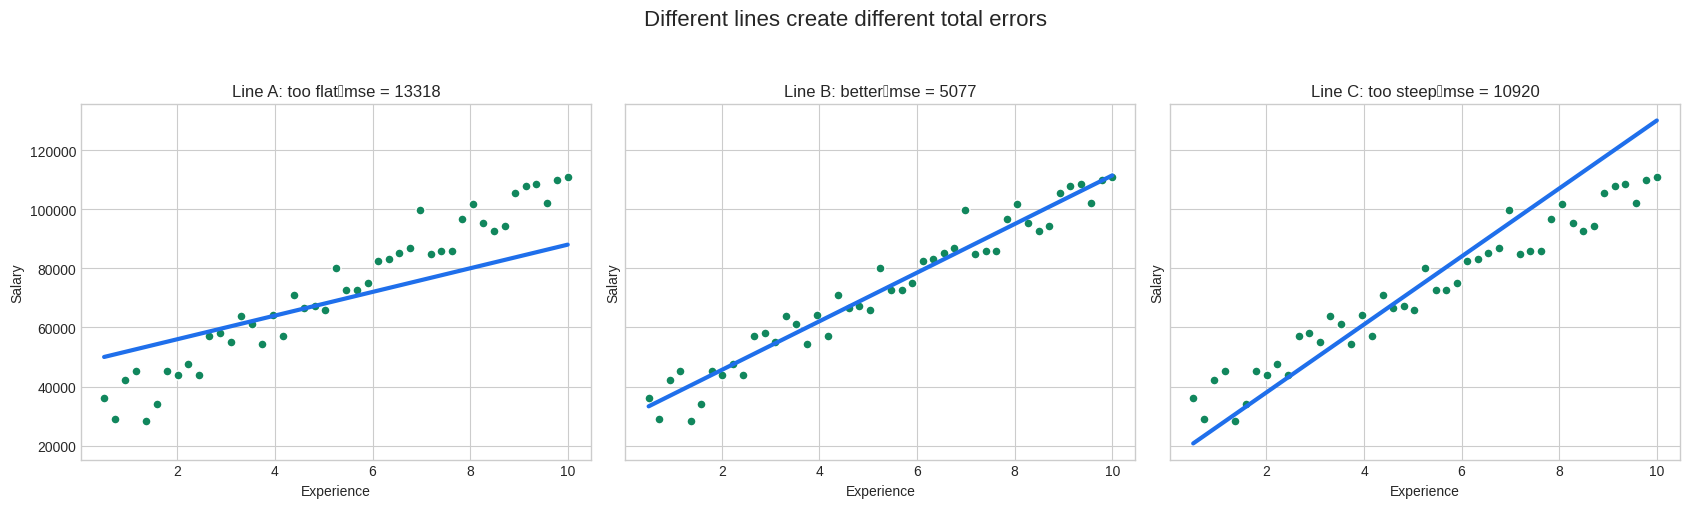

In [36]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.8), sharey=True)

for ax, model in zip(axes, candidate_models):
    y_pred = predict_line(x, model["slope"], model["intercept"])
    metrics = regression_metrics(y, y_pred)
    ax.scatter(x, y, s=42, color="#11875d", edgecolor="white")
    ax.plot(x, y_pred, color="#1f6feb", linewidth=3)
    ax.set_title(f"{model['name']}\rmse = {metrics['rmse']:.0f}", fontsize=12)
    ax.set_xlabel("Experience")
    ax.set_ylabel("Salary")

plt.suptitle("Different lines create different total errors", fontsize=16, y=1.05)
plt.tight_layout()
plt.show()

### **Cell 8: Calculating Optimal Beta Coefficients (OLS)**

This cell calculates the optimal slope (`beta_1`) and intercept (`beta_0`) for a simple linear regression model using the Ordinary Least Squares (OLS) method. This method directly computes the coefficients that minimize the sum of squared residuals.

In [37]:
x_mean = np.mean(x)
y_mean = np.mean(y)

beta_1 = np.sum((x - x_mean) * (y - y_mean)) / np.sum((x - x_mean) ** 2)
beta_0 = y_mean - beta_1 * x_mean

beta_1, beta_0

(np.float64(8224.170483411222), np.float64(29184.266046449906))

### **Cell 9: Pseudocode for Gradient Descent**

This cell provides a high-level outline of the steps involved in a gradient descent algorithm, which is an iterative optimization method used to find the minimum of a function (in this case, minimizing the error of the regression model).

initialize betas with some random value

for each sample
    1. do forward pass - linear reg formula
    2. error calculation
    3. Compute the gradient
    4. update betas

### **Cell 10: Gradient Descent Implementation**

This cell defines the `gradient_descent_simple` function, which implements the gradient descent algorithm. It initializes random `b0` and `b1` values, then iteratively updates them by calculating the gradient of the MSE with respect to `b0` and `b1` and moving in the direction that reduces the error. It also stores the history of `b0`, `b1`, and MSE over epochs.

In [38]:
x_scaled = (x - x_mean) / x.std() # scaled data has zero mean and unit standard deviation
y_k = y / 1000

def gradient_descent_simple(x_input, y_target, learning_rate=0.05, epochs=300):
    b0 = np.random.randn()
    b1 = np.random.randn()

    n = len(y_target)
    history = []

    for epoch in range(epochs+1):
        # forward pass
        y_hat = b0 + b1 * x_input
        error = (y_target - y_hat)
        mse = np.mean(error ** 2)

        history.append({
            "epoch": epoch,
            "b0": b0,
            "b1": b1,
            "mse": mse
        })

        # gradient calculation
        grad_b1 = -(1/n) * np.sum(error * x_input)
        grad_b0 = -(1/n) * np.sum(error)

        # weight update / backpropagation
        b0 = b0 - learning_rate * grad_b0
        b1 = b1 - learning_rate * grad_b1

    return pd.DataFrame(history)

### **Cell 11: Running and Inspecting Gradient Descent History**

This cell executes the `gradient_descent_simple` function with scaled input data and a specified learning rate. It then displays the last few entries of the `gd_history` DataFrame, showing the final `b0`, `b1`, and `mse` values achieved by the algorithm.

In [39]:
gd_history = gradient_descent_simple(x_scaled, y_k, learning_rate=1.6)
gd_history.tail()

,epoch,b0,b1,mse
296,296,72.361161,23.060975,25.777903
297,297,72.361161,23.060975,25.777903
298,298,72.361161,23.060975,25.777903
299,299,72.361161,23.060975,25.777903
300,300,72.361161,23.060975,25.777903


### **Cell 12: Visualizing Gradient Descent Cost**

This cell plots the Mean Squared Error (MSE) against the number of epochs from the `gd_history`. This visualization shows how the cost function (MSE) decreases over iterations, demonstrating the convergence of the gradient descent algorithm.

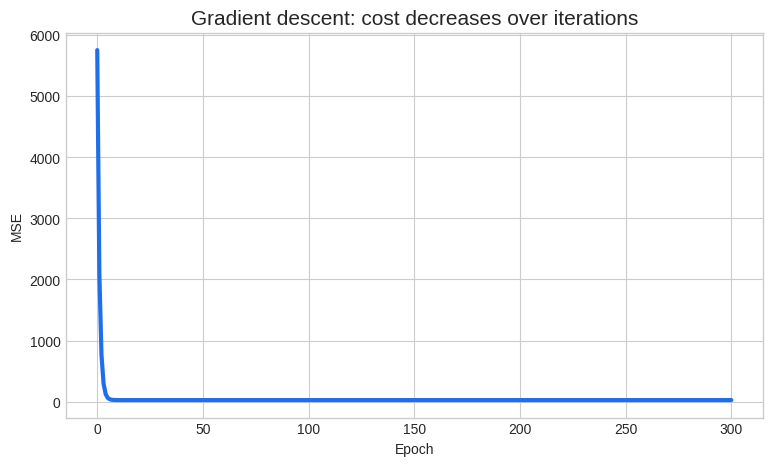

In [40]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(gd_history["epoch"], gd_history["mse"], color="#1f6feb", linewidth=3)
ax.set_title("Gradient descent: cost decreases over iterations", fontsize=15)
ax.set_xlabel("Epoch")
ax.set_ylabel("MSE")
plt.show()

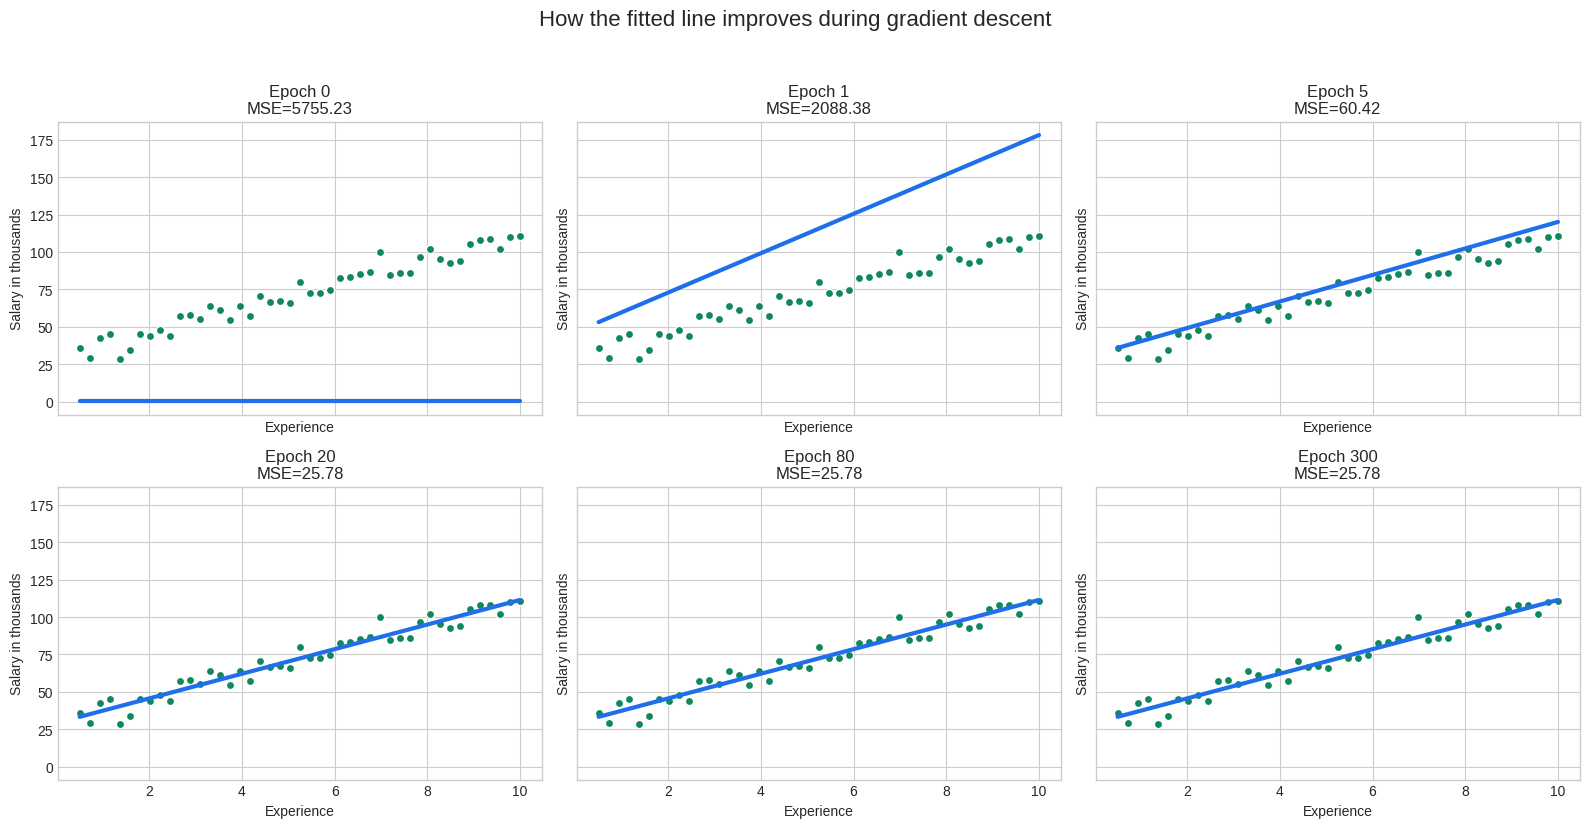

In [41]:
def plot_gd_lines_at_epochs(history, selected_epochs):
    fig, axes = plt.subplots(2, 3, figsize=(16, 8), sharex=True, sharey=True)
    axes = axes.ravel()

    for ax, epoch in zip(axes, selected_epochs):
        row = history.loc[history["epoch"] == epoch].iloc[0]
        pred_k = row["b0"] + row["b1"] * x_scaled

        ax.scatter(x, y_k, s=35, color="#11875d", edgecolor="white")
        ax.plot(x, pred_k, color="#1f6feb", linewidth=3)
        ax.set_title(f"Epoch {epoch}\nMSE={row['mse']:.2f}", fontsize=12)
        ax.set_xlabel("Experience")
        ax.set_ylabel("Salary in thousands")

    plt.suptitle("How the fitted line improves during gradient descent", fontsize=16, y=1.03)
    plt.tight_layout()
    plt.show()

plot_gd_lines_at_epochs(gd_history, selected_epochs=[0, 1, 5, 20, 80, 300])

In [42]:
try:
    # Attempt to import LinearRegression from scikit-learn
    from sklearn.linear_model import LinearRegression

    # Initialize the LinearRegression model
    model = LinearRegression()
    # Fit the model to the data; x needs to be reshaped for scikit-learn
    model.fit(x.reshape(-1, 1), y)

    # Print the intercept found by scikit-learn
    print("sklearn intercept:", model.intercept_)
    # Print the slope found by scikit-learn
    print("sklearn slope:", model.coef_[0])
    # Print the intercept calculated from the custom OLS implementation
    print("from-scratch intercept:", beta_0)
    # Print the slope calculated from the custom OLS implementation
    print("from-scratch slope:", beta_1)
except ImportError:
    # If scikit-learn is not installed, inform the user
    print("scikit-learn is not installed in this environment. The from-scratch OLS code above is enough for Session 1.")

sklearn intercept: 29184.266046449906
sklearn slope: 8224.170483411222
from-scratch intercept: 29184.266046449906
from-scratch slope: 8224.170483411222


### **Explanation of `model.fit(x.reshape(-1, 1), y)`**

This line is fundamental to training (or "fitting") a machine learning model using scikit-learn. Let's break down its components:

*   **`model.fit(X, y)`:**
    *   This is a standard method available in virtually all scikit-learn estimator objects (like `LinearRegression`).
    *   Its purpose is to **train the model** by adjusting its internal parameters (in the case of linear regression, the slope and intercept) to best describe the relationship between the input features (`X`) and the target variable (`y`).
    *   `X` typically represents the input features (independent variables), and `y` represents the target (dependent variable) that the model tries to predict.

*   **`x.reshape(-1, 1)`:**
    *   **`x`** here is your `experience_years` data, which is currently a 1-dimensional NumPy array (e.g., `[0.5, 0.71, ..., 10.0]`).
    *   Scikit-learn models, by convention, expect the input features `X` to be a 2-dimensional array. Even if you have only one feature, it needs to be represented as a column vector (a 2D array with one column).
    *   **`reshape(-1, 1)`** is a NumPy method that transforms the shape of an array:
        *   The `-1` tells NumPy to automatically calculate the size of that dimension. In this case, it means "make as many rows as needed".
        *   The `1` explicitly states that we want `1` column.
    *   So, if `x` was `[a, b, c]`, `x.reshape(-1, 1)` would turn it into `[[a], [b], [c]]`. This converts our 1D feature array into a 2D array with one column, which is the format scikit-learn expects for its input features `X`.

*   **`y`:**
    *   This is your `salary` data, which is also a 1-dimensional NumPy array.
    *   Scikit-learn models typically accept the target `y` as a 1D array, so no reshaping is needed for `y` in this context.

**In summary,** `model.fit(x.reshape(-1, 1), y)` tells the `LinearRegression` model to learn the best linear relationship between the reshaped `experience_years` (as input features) and `salary` (as the target variable) by finding the optimal slope and intercept that minimize the prediction errors.

## Notebook Summary

This notebook is a comprehensive tutorial on linear regression, demonstrating both the Ordinary Least Squares (OLS) method and Gradient Descent from scratch. Here's a summary of its key sections:

*   **Setup and Data Generation:** It begins by importing necessary libraries (NumPy, Pandas, Matplotlib) and generating synthetic data for 'experience years' and 'salary', ensuring reproducibility with a fixed random seed.
*   **Initial Data Visualization:** The generated data is visualized using a scatter plot to show the relationship between experience and salary.
*   **Regression Helper Functions:** Helper functions are defined to predict values based on a given line (slope and intercept) and to plot regression lines along with their residuals, which visually represent the errors.
*   **Regression Metrics:** A function to calculate common regression metrics like RSS, MSE, RMSE, and MAE is provided to quantitatively evaluate model performance.
*   **Candidate Model Comparison:** Several candidate linear regression models with different slopes and intercepts are defined and their performance is compared using the defined metrics and visualizations.
*   **Ordinary Least Squares (OLS):** The notebook then calculates the optimal slope (`beta_1`) and intercept (`beta_0`) directly using the Ordinary Least Squares (OLS) method, which minimizes the sum of squared residuals.
*   **Gradient Descent Implementation:** It introduces and implements the Gradient Descent algorithm, an iterative optimization technique, to find the optimal regression coefficients by gradually minimizing the Mean Squared Error (MSE). The process of how the cost decreases over iterations and how the fitted line improves over epochs is visualized.
*   **Scikit-learn Comparison:** Finally, the results from the custom OLS and Gradient Descent implementations are compared with the `LinearRegression` model from scikit-learn to validate the from-scratch implementations.